# Đề thi Giữa kỳ Graph mining 2024.

### Khoa học dữ liệu IUH. Ca 2. Thời gian làm bài: 90 phút (được dùng tài liệu Internet).

### Bài 1. (2.5 = 0.5+1+1đ)

Bài này dựa trên bộ data có sẵn Zachary's Karate Club của thư viện networkx. Hãy thực hiện các yêu cầu sau:

1) Import graph này và trực quan nó ở dạng spring_layout.

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx


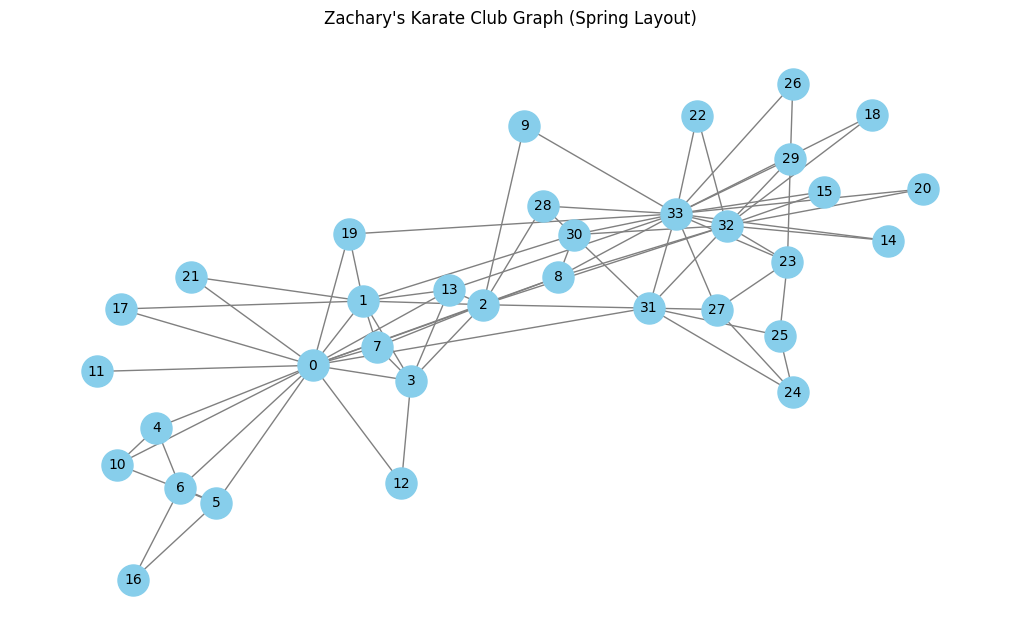

In [5]:
# Import đồ thị Zachary's Karate Club từ thư viện NetworkX
G = nx.karate_club_graph()

# Trực quan đồ thị ở dạng spring_layout
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=500, edge_color='gray', linewidths=1, font_size=10)
plt.title("Zachary's Karate Club Graph (Spring Layout)")
plt.show()


2) Gọi $a,b$ lần lượt là chữ số lớn nhất và nhỏ nhất (nhưng lớn hơn $2$) trong MSSV của anh/chị. Hãy cho biết giữa hai đỉnh với index $a,b$ thì có cạnh nối nhau hay không. Đồng thời tô màu đỏ cho đường đi ngắn nhất giữa hai đỉnh đó. Gợi ý: anh/chị có thể tra cứu từ khóa *highlight the shortest path in networkx graph*.

In [19]:
mssv = '21068521'
a = 8
b = 5
# Kiểm tra xem có cạnh nối giữa hai đỉnh không
if G.has_edge(a, b):
    print("Có cạnh nối giữa đỉnh", a, "và đỉnh", b)
else:
    print("Không có cạnh nối giữa đỉnh", a, "và đỉnh", b)

Không có cạnh nối giữa đỉnh 8 và đỉnh 5


In [20]:
shortest_path = nx.shortest_path(G, source=a, target=b)
print("Đường đi ngắn nhất giữa hai đỉnh là:", shortest_path)

Đường đi ngắn nhất giữa hai đỉnh là: [8, 0, 5]


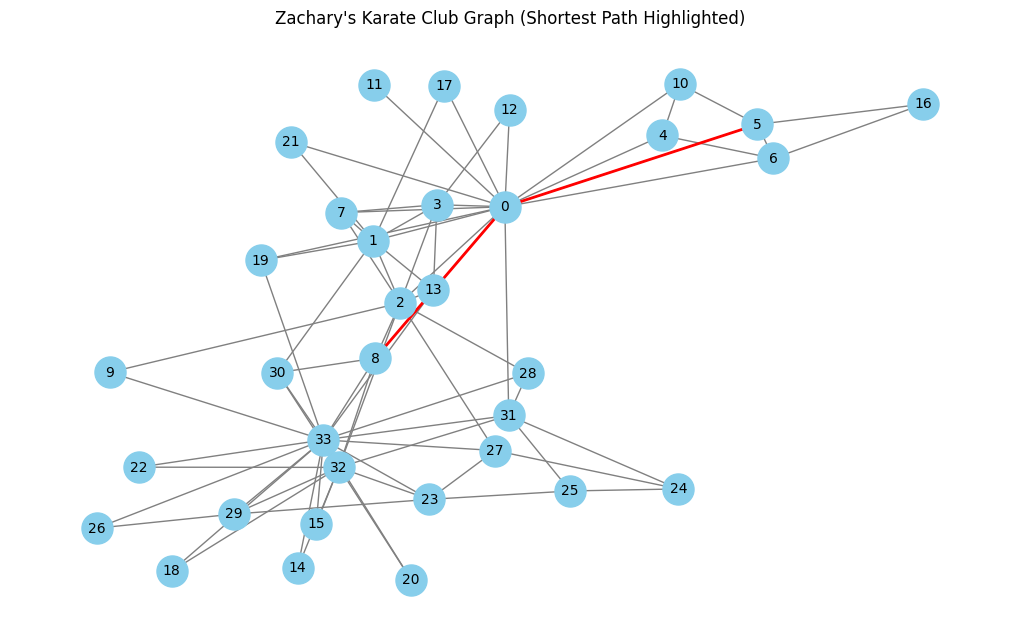

In [22]:
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=500, edge_color='gray', linewidths=1, font_size=10)

# Tô màu đỏ cho đường đi ngắn nhất giữa hai đỉnh
edges = [(shortest_path[i], shortest_path[i+1]) for i in range(len(shortest_path)-1)]
nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color='red', width=2)

plt.title("Zachary's Karate Club Graph (Shortest Path Highlighted)")
plt.show()

3) Hãy tìm kích thước của một nhóm con lớn nhất trong câu lạc bộ gồm những người đôi một không quen nhau (tập độc lập) bằng **cả hai cách**: dùng *maximum_independent_set* hoặc xây dựng graph bù rồi dùng *max_clique*. 


In [104]:
max_independent_set = nx.maximal_independent_set(G,seed=4)
print("Tập độc lập lớn nhất trong đồ thị là:", max_independent_set)
print("Tập độc lập lớn nhất trong đồ thị là : ",nx.approximation.maximum_independent_set(G))
print("Kích thước của tập độc lập lớn nhất là:", len(max_independent_set))

# Cách 2 : xây dựng graph bù rồi tìm tập độc lập lớn nhất bằng max_clique
complement_graph = nx.complement(G)
max_size = max(len(i) for i in list(nx.find_cliques(complement_graph)))
print("Kích thước của tập độc lập lớn nhất theo graph bù là:", max_size)

Tập độc lập lớn nhất trong đồ thị là: [15, 9, 4, 30, 21, 25, 12, 7, 11, 5, 22, 28, 19, 13, 17, 27, 29, 18, 14, 20]
Tập độc lập lớn nhất trong đồ thị là :  {4, 5, 7, 8, 9, 11, 12, 14, 15, 17, 18, 19, 20, 21, 22, 23, 24, 26, 28}
Kích thước của tập độc lập lớn nhất là: 20
Kích thước của tập độc lập lớn nhất theo graph bù là: 20


### Bài 2. (2.0 = 1 + 1đ) Trong BA chọn HAI:

1) Cho graph $G$ được mô tả bởi thông tin bên dưới. Tính giá trị của hệ số trung tâm betweeness của đỉnh $4$ bằng hai cách: dùng thư viện và tính toán trực tiếp.

In [245]:
G_sample1 = {
  '1' : ['2', '3'],
  '2' : ['1', '3'],
  '3' : ['1', '2', '4'],
  '4' : ['3', '5'],
  '5' : ['4', '6'],
  '6' : ['5']
}
G_sample1 = nx.Graph(G_sample1)

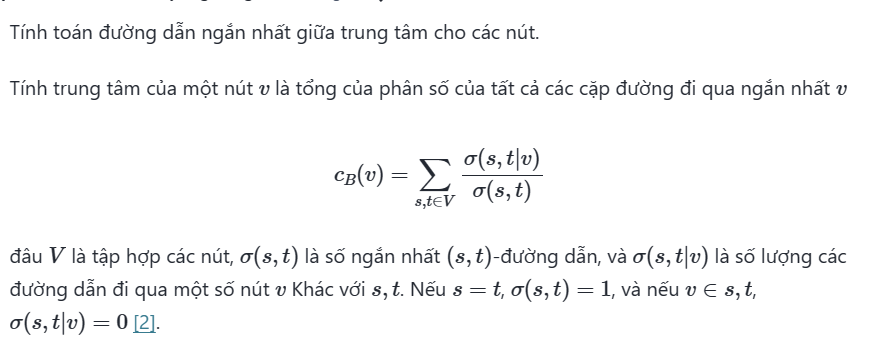

$c_B(v) = \sum_{s,t \in V} \frac{\sigma(s, t|v)}{\sigma(s, t)}$

In [286]:
# Tính giá trị của betweenness centrality đỉnh 4 bằng 2 cách
# Cách 1: Sử dụng hàm betweenness_centrality
betweenness = nx.betweenness_centrality(G_sample1)
betweenness_4 = betweenness['4']
print("hệ số trung tâm betweeness của đỉnh 4 trong đồ thị là:", betweenness['4'])


hệ số trung tâm betweeness của đỉnh 4 trong đồ thị là: 0.6000000000000001


In [287]:

# Cách 2: Tính giá trị betweenness centrality của đỉnh 4 bằng công thức $c_B(v) = \sum_{s,t \in V} \frac{\sigma(s, t|v)}{\sigma(s, t)}$
def shortest_paths(graph):
    paths = {}
    for source in graph:
        paths_from_source = nx.single_source_shortest_path(graph, source)
        paths[source] = paths_from_source
    return paths

def count_shortest_paths(graph):
    paths = shortest_paths(graph)
    count = {}
    for source in paths:
        for target in paths[source]:
            if source != target:
                for path in paths[source][target]:
                    for node in path[1:-1]:
                        count[node] = count.get(node, 0) + 1
    return count

def betweenness_centrality(graph):
    num_paths = count_shortest_paths(graph)
    total_paths = nx.shortest_path(graph)
    betweenness = {}
    for node in graph:
        node_paths = num_paths.get(node, 0)
        total = sum(len(total_paths[source][target]) for source in total_paths for target in total_paths[source] if source != target)
        betweenness[node] = node_paths / total
    return betweenness


# Chuyển đổi đồ thị sang dạng NetworkX
G = nx.Graph(G_sample1)

# Tính giá trị betweenness centrality của đỉnh 4
betweenness = betweenness_centrality(G)
# betweenness_4 = betweenness['4']
print("Betweenness centrality của đỉnh 4 là:", betweenness_4)

Betweenness centrality của đỉnh 4 là: 0.6000000000000001


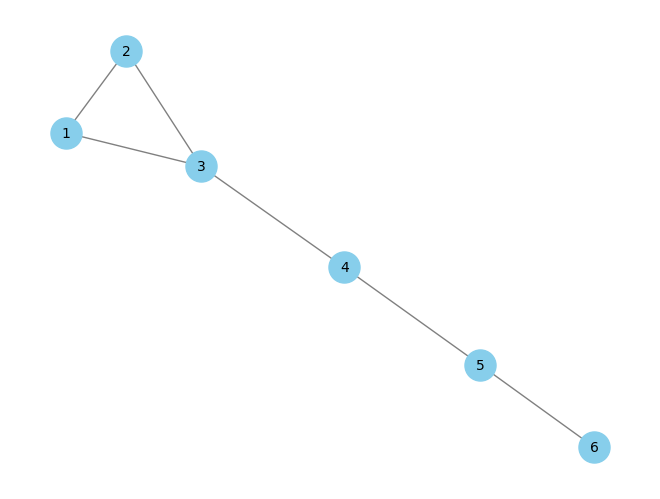

In [108]:
nx.draw(G_sample1, with_labels=True, node_color='skyblue', node_size=500, edge_color='gray', linewidths=1, font_size=10)

2) Quản lý dự án Tuấn có liệt kê danh sách cách công việc giao cho nhân viên phát triển phần mềm Nam để thực hiện, các công việc gồm $A$, $B$, $C$, $D$, $E$, $F$, $G$ với thứ tự ưu tiên như sau:
- $A$ phải thực hiện trước $E, F$.
- $B, C$ phải thực hiện trước $G$.
- $G$ phải thực hiện trước $E$.
- $D$ sẽ được thực hiện cuối cùng.

Bạn Nam muốn mô tả bài toán ở trên thành graph có hướng rồi sử dụng hàm topological_sort của networkx để đưa ra một phương án thực hiện công việc thỏa mãn các thứ tự nêu trên. Anh/chị hãy giúp Nam nhé.

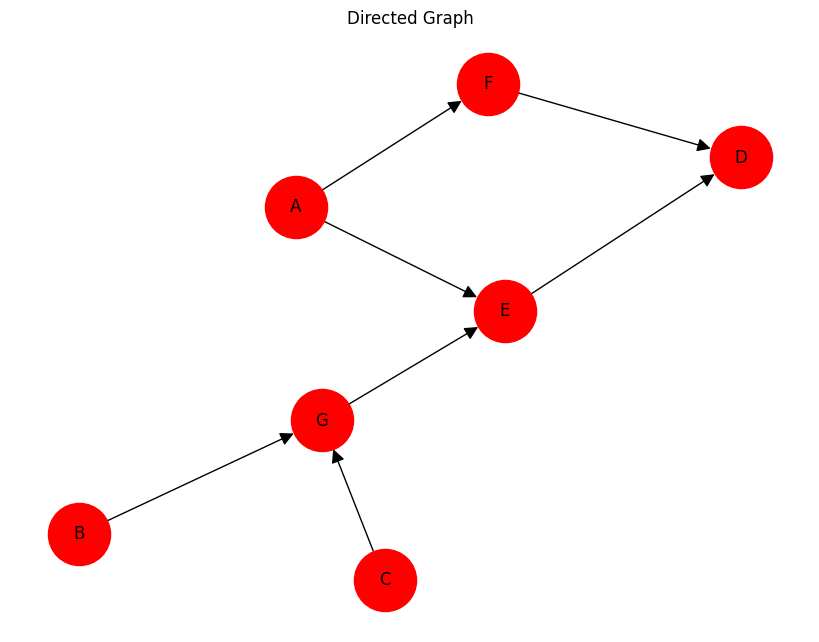

In [240]:
G = nx.DiGraph()

G.add_nodes_from(['A', 'B', 'C', 'D', 'E', 'F', 'G'])

G.add_edges_from([
    ('A', 'E'), ('A', 'F'), 
    ('B', 'G'), ('C', 'G'), 
    ('G', 'E'), 
    ('E', 'D'),('F', 'D')])

# Vẽ đồ thị
plt.figure(figsize=(8, 6))
nx.draw(G, with_labels=True, node_color='red', node_size=2000, font_size=12, arrowsize=20)
plt.title('Directed Graph')
plt.show()

In [241]:
topological_order = list(nx.topological_sort(G))
print("Order of tasks for execution:", topological_order)

Order of tasks for execution: ['A', 'B', 'C', 'F', 'G', 'E', 'D']


3) Cho graph $H$ như bên dưới. Hỏi nếu thêm vào $H$ tất cả $3$ cạnh mới thì sẽ tạo được nhiều nhất mấy chu trình? Vẽ lên graph $H$ một cách thêm cạnh thỏa mãn điều đó.

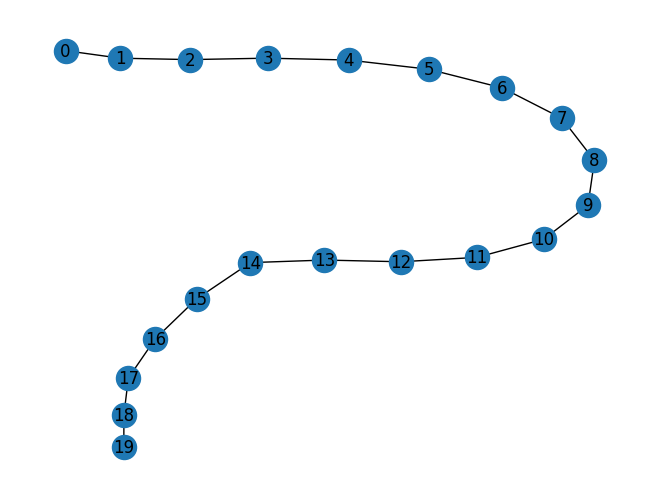

In [242]:
H = nx.path_graph(20)
nx.draw(H, with_labels = True)

### Bài 3. (2.5 = 1 + 1 + 0.5đ)

Sinh ngẫu nhiên $10$ graph đơn vô hướng, mỗi graph có $15$ đỉnh và $92$ cạnh có trọng số nguyên thuộc miền $[0,23]$. Từ đó, thực hiện các yêu cầu sau:

1) Tính **trung bình cộng** của các đại lượng sau đây:

- Trọng số của cây khung nhỏ nhất.
- Độ dài đường đi ngắn nhất từ đỉnh $a-b$ đến đỉnh $a+b$, trong đó $a,b$ lần lượt là chữ số lớn nhất và nhỏ nhất (nhưng lớn hơn $2$) trong MSSV của anh/chị.

In [272]:
data = [] # lưu các graph sinh ra được vào list này
minimum_spanning_tree = 0
shortest_path_length = 0
for _ in range(10):
    G3 = nx.gnm_random_graph(27, 92,directed=False)
    for (u, v) in G3.edges():
        G3.edges[u, v]['weight'] = np.random.randint(0, 24) 
    data.append(G3)
    T = nx.minimum_spanning_tree(G3, algorithm='kruskal')
    # Tính tổng trọng số của cây khung nhỏ nhất
    total_weight = sum([G3[u][v]['weight'] for u, v in T.edges()])
    minimum_spanning_tree += total_weight

    # Tính độ dài đường đi ngắn nhất từ đỉnh 3 đến đỉnh 13
    print(nx.dijkstra_path(G3, source=3, target=13))
    # print(nx.shortest_path_length(G3, source=3, target=13, weight='weight'))
    shortest_path_length += len(nx.dijkstra_path(G3, source=3, target=13))

# Tính trung bình cộng của trọng số của cây khung nhỏ nhất
average_minimum_spanning_tree = minimum_spanning_tree / 10
print("Trung bình cộng của trọng số của cây khung nhỏ nhất là:", average_minimum_spanning_tree)
average_shortest_path_length = shortest_path_length / 10
print("Trung bình cộng của độ dài đường đi ngắn nhất từ đỉnh 3 đến đỉnh 13 là:", average_shortest_path_length)

[3, 13]
[3, 14, 13]
[3, 1, 4, 12, 5, 6, 13]
[3, 26, 4, 22, 13]
[3, 26, 2, 13]
[3, 7, 0, 6, 25, 22, 18, 13]
[3, 10, 18, 6, 26, 13]
[3, 0, 9, 13]
[3, 20, 12, 13]
[3, 26, 12, 17, 13]
Trung bình cộng của trọng số của cây khung nhỏ nhất là: 98.9
Trung bình cộng của độ dài đường đi ngắn nhất từ đỉnh 3 đến đỉnh 13 là: 4.8


2) Với các graph ở trên (sử dụng list data đã tạo, không được sinh lại các graph mới), hãy cho biết **giá trị lớn nhất** của:
- Số cạnh cầu.
- Số đỉnh khớp.

In [276]:
max_number_of_bridges = 0
max_number_of_cut_vertices = 0
for G3 in data:
    bridges = list(nx.bridges(G3))
    cut_vertices = list(nx.articulation_points(G3))
    max_number_of_bridges = max(max_number_of_bridges, len(bridges))
    max_number_of_cut_vertices = max(max_number_of_cut_vertices, len(cut_vertices))
                                     
print("Giá trị lớn nhất của số cạnh cầu là:", max_number_of_bridges)
print("Giá trị lớn nhất của số đỉnh khớp là:", max_number_of_cut_vertices)


Giá trị lớn nhất của số cạnh cầu là: 1
Giá trị lớn nhất của số đỉnh khớp là: 1


3) Giải thích tại sao các graph có $15$ đỉnh và $92$ cạnh như trên thì số thành phần liên thông luôn là $1$?

Graph có 15 đỉnh và 92 cạnh, nếu không có chu trình thì số thành phần liên thông sẽ bằng 1. Vì số cạnh tối đa của một đồ thị không có chu trình là $n-1$ với $n$ là số đỉnh của đồ thị. Trong trường hợp này, số cạnh của đồ thị là 92, nên nếu không có chu trình thì số thành phần liên thông sẽ bằng 1.

### Bài 4. (2.5 = 1+1+0.5đ)

Sử dụng dataset về các nhà toán học có trong file **data_cleaned.csv** được cho trước, trong đó có $5$ cột và $8596$ dòng, ta chỉ quan tâm đến hai cột chính là *mathematicians* (họ tên) và *doctoral advisor* (người hướng dẫn) vì các thông tin này cho biết mối quan hệ giữa họ. Chú ý rằng nếu $A$ hướng dẫn cho $B$ thì $A$ là thầy của $B$, còn $B$ là học trò của $A$. Hãy thực hiện các yêu cầu sau:

1) Điều chỉnh lại data sao cho chỉ còn hai cột như trên, đồng thời lọc dữ liệu sao cho chỉ giữ lại những nhà toán học có thông tin của người hướng dẫn (bỏ đi các dòng bị thiếu thông tin đó); 

In [213]:
# SV chỉ cần chạy code có sẵn này để đọc dữ liệu
import pandas as pd
df = pd.read_csv('data_cleaned.csv')
df = df[['mathematicians', 'doctoral advisor']]
df = df.dropna().reset_index(drop=True)
df

C:\Users\Admin\AppData\Local\Temp\ipykernel_19112\1376788283.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


,mathematicians,doctoral advisor
0,Emma Previato,David Mumford
1,Alexander Grothendieck,Laurent Schwartz
2,Ljubomir Chakaloff,"Ernesto Pascal', '1925"
3,Nikolay Bogolyubov,Nikolay Mitrofanovich Krylov
4,C. S. Seshadri,K. S. Chandrasekharan
...,...,...
2445,Raymond Woodard Brink,George David Birkhoff
2446,Arnaud Beauville,Jean-Louis Verdier
2447,Iain S. Duff,Leslie Fox
2448,Boáz Klartag,Vitali Milman


Tiếp theo là chuyển dataframe df ở trên sang dữ liệu DiGraph (graph có hướng):

In [218]:
# Tiếp theo là chuyển dataframe df ở trên sang dữ liệu DiGraph (graph có hướng):
G4 = nx.DiGraph()
for i in range(len(df)):
    advisor = df.loc[i, 'doctoral advisor']
    mathematician = df.loc[i, 'mathematicians']
    if advisor not in G4:
        G4.add_node(advisor)
    if mathematician not in G4:
        G4.add_node(mathematician)
    G4.add_edge(advisor, mathematician)

2) Thực hiện thuật toán pagerank bằng hàm có sẵn của thư viện networkx. In ra bảng sắp thứ tự tên của top 10 các nhà Toán học có rank cao nhất dựa theo kết quả chạy thuật toán PageRank. 

In [230]:
pr = pd.DataFrame([{'name': name, 'pagerank': pagerank} for name, pagerank in nx.pagerank(G4).items()])
pr.sort_values('pagerank', ascending=False).head(10)

,name,pagerank
1018,Mónica Clapp,0.000871
2460,Øystein Ore,0.000863
937,András Frank,0.000813
138,Domenico Maria Novara da Ferrara,0.000813
1643,Peter James Lorimer,0.000789
1525,Allen Knutson,0.000772
1017,Albrecht Dold,0.000769
223,Dennis DeTurck,0.000765
1710,Jean-Louis Colliot-Thélène,0.000764
1809,Gene H. Golub,0.000755


In [231]:
# thực hiện thuật toán Pagerank và in ra top 10 người có rank cao nhất
p_rank = nx.pagerank(G4)
top_10 = sorted(p_rank, key=p_rank.get, reverse=True)[:10]
for i, mathematician in enumerate(top_10):
    print(f"Vị trí thứ {i+1} trong bảng xếp hạng Pagerank là: {mathematician}")

Vị trí thứ 1 trong bảng xếp hạng Pagerank là: Mónica Clapp
Vị trí thứ 2 trong bảng xếp hạng Pagerank là: Øystein Ore
Vị trí thứ 3 trong bảng xếp hạng Pagerank là: Domenico Maria Novara da Ferrara
Vị trí thứ 4 trong bảng xếp hạng Pagerank là: András Frank
Vị trí thứ 5 trong bảng xếp hạng Pagerank là: Peter James Lorimer
Vị trí thứ 6 trong bảng xếp hạng Pagerank là: Allen Knutson
Vị trí thứ 7 trong bảng xếp hạng Pagerank là: Albrecht Dold
Vị trí thứ 8 trong bảng xếp hạng Pagerank là: Dennis DeTurck
Vị trí thứ 9 trong bảng xếp hạng Pagerank là: Jean-Louis Colliot-Thélène
Vị trí thứ 10 trong bảng xếp hạng Pagerank là: Gene H. Golub


3) Trực quan dữ liệu pagerank p_rank dựa theo code mẫu bên dưới:

In [ ]:
# SV chỉ cần chạy code có sẵn này để xuất ra dữ liệu
import matplotlib.pyplot as plt
names, ranks = zip(*p_rank.items())
pr_df = pd.DataFrame(data={'name': names, 'rank': ranks})
fig = plt.figure(1, figsize=(30, 20), dpi=100)
pos = nx.spring_layout(G4, k=1.1*1/np.sqrt(len(G4.nodes())), iterations=20)
nx.draw(G4, node_size=pr_df['rank'].values*10000, with_labels=True, pos=pos, edge_color='gray')
plt.show()

### Bài 5. (0.5 điểm)

Chu trình Euler trên graph đơn vô hướng $G$ là chu trình đi qua tất cả các cạnh của $G$, mỗi cạnh đúng một lần. Ta biết rằng điều kiện để có được tính chất này là $G$ phải liên thông và bậc tất cả các đỉnh đều chẵn. Hỏi cần bỏ đi ít nhất bao nhiêu cạnh của một graph đầy đủ (completed graph) có $2024$ đỉnh sao cho graph mới thu được sẽ có chu trình Euler?

vì mỗi cạnh được chia sẻ bởi hai đỉnh, mỗi cạnh bị loại bỏ sẽ giảm bậc của đúng hai đỉnh. Do đó, để giảm bậc của mỗi đỉnh từ 2023 xuống 2022, chúng ta cần loại bỏ ít nhất $\frac{2024}{2}$ cạnh, vì mỗi cạnh loại bỏ sẽ ảnh hưởng đến hai đỉnh.

In [288]:
def edges_to_remove_for_euler_cycle(vertices):
    if (vertices - 1) % 2 == 1:
        return vertices / 2
    else:
        return 0

# Số đỉnh của graph đầy đủ
vertices = 2024

# Tính toán và in ra số cạnh cần loại bỏ
edges_to_remove = edges_to_remove_for_euler_cycle(vertices)
print(f"Số cạnh cần loại bỏ để có chu trình Euler: {int(edges_to_remove)}")

Số cạnh cần loại bỏ để có chu trình Euler: 1012
